# Mystery Dataset 1: From Data Wrangling to End-to-End Machine Learning

### Hands-On AI/ML for Biomedical Science and Engineering

This notebook takes the **mystery dataset** you have already explored and uses it to walk through many of the same ideas as an end-to-end machine-learning project. It is configured for **interactive Matplotlib figures in Google Colab**, and the same plotting approach also works in VS Code/Jupyter when `ipympl` is installed.

We will use the same dataset in **two different ways**:

1. **Supervised regression:** can we predict `Step_Height` for an animal the model has never seen before?
2. **Unsupervised discovery:** can multivariate recovery patterns help us guess which animals were treated, before the treatment identities are revealed?

---

## Learning goals

By the end, you should be able to:

- inspect a new biomedical dataset and identify its structure
- distinguish identifiers, experimental conditions, features, and outcomes
- recognize missing data and suspicious outliers
- define the **unit of independent generalization**
- make a train/test split that respects repeated measurements
- build useful derived features
- construct a preprocessing pipeline
- compare regression models with grouped cross-validation
- evaluate a final model on untouched animals
- recognize collinearity and redundant predictors
- think critically about target leakage, proxy variables, and feature availability
- reduce longitudinal biomechanics data to one row per animal
- use PCA and clustering for a blind exploratory treatment guess

---

## A Geron Chapter 2-style workflow - but with BME data rather than real-estate

A useful machine-learning workflow is:

1. Frame the problem
2. Get and inspect the data
3. Set aside a test set
4. Explore the training data
5. Prepare the data
6. Select and train models
7. Evaluate and fine-tune
8. Interpret, communicate, and sanity-check the result

The details change in biomedical science because observations are often **repeated, hierarchical, longitudinal, and correlated within subjects**.

The concepts in Geron Chapter 2 that we're ommittig are...

# 0. Setup

This notebook expects `mystery_dataset_1.csv` to be either:

- in the same folder as the notebook,
- in a `data/` folder,
- or one directory above in `data/`.

In Colab, you can also simply upload the CSV into the runtime before running this cell.

## Interactive plotting setup

For this course, we will use Matplotlib in two modes:

- **interactive exploration**: zoom, pan, inspect points
- **finished output**: export a reproducible figure with `fig.savefig(...)`

This notebook targets **Google Colab** first. The next cell installs `ipympl` and `mplcursors` in Colab and enables Colab's widget manager.

In a local VS Code/Jupyter environment, install these once in the course environment:

```bash
conda install -c conda-forge ipympl mplcursors
```

Then the same `%matplotlib widget` command gives interactive figures inside the notebook.

To return to static notebook figures at any time:

```python
%matplotlib inline
```

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "ipympl", "mplcursors"],
        check=True,
    )

    from google.colab import output
    output.enable_custom_widget_manager()

# Interactive Matplotlib backend in Colab, VS Code, or JupyterLab.
%matplotlib widget

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_validate,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

pd.set_option("display.max_columns", 100)

In [8]:
candidate_paths = [
    Path("mystery_dataset_1.csv"),
    Path("data/mystery_dataset_1.csv"),
    Path("../data/mystery_dataset_1.csv"),
    Path("/content/drive/MyDrive/mystery_dataset_1.csv")
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find mystery_dataset_1.csv. "
        "Put it beside this notebook, in data/, or upload it to the Colab runtime."
    )

df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)

df.head()

Loaded: mystery_dataset_1.csv
Shape: (16022, 37)


,Unnamed: 0,Name_File,Study,Speed_Group,Timepoint_Name,Rat,Belt_Speed,Trial_Name,Stride,Step_Length,Step_Duration,Stance_Duration,Step_Height,Mean_Asis_Toe_Height,Variation_Asis_Toe_Height,Mean_Asis_Toe_Height_Stance,Variation_Asis_Toe_Height_Stance,Mean_Asis_Toe_Height_Swing,Variation_Asis_Toe_Height_Swing,Mean_Ankle,Variation_Ankle,Mean_Ankle_Stance,Variation_Ankle_Stance,Mean_Ankle_Swing,Variation_Ankle_Swing,Mean_Knee,Variation_Knee,Mean_Knee_Stance,Variation_Knee_Stance,Mean_Knee_Swing,Variation_Knee_Swing,Mean_Hip,Variation_Hip,Mean_Hip_Stance,Variation_Hip_Stance,Mean_Hip_Swing,Variation_Hip_Swing
0,0,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,speed16,week-1,155,0.16,2020-07-13_11_06_34,1.0,14.250848,0.352,0.164,18.737377,56.296479,4.583828,59.560016,2.062233,53.449565,4.273980,33.224371,10.486945,24.578297,9.028981,40.766691,6.158053,83.365409,14.153212,91.213741,10.838977,76.518992,13.187140,147.381546,10.486945,150.301392,7.905640,144.834447,11.807772
1,1,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,speed16,week-1,155,0.16,2020-07-13_11_06_34,2.0,11.564196,0.528,0.392,14.698949,54.436352,3.978109,55.578158,3.188863,51.145263,4.230895,20.725727,14.103204,16.938196,11.491799,31.642728,7.490715,80.266893,10.704809,82.576667,8.665695,73.609311,13.139925,153.670965,14.103204,156.074960,13.672349,146.741802,13.170929
2,2,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,speed16,week-1,155,0.16,2020-07-13_11_06_34,3.0,21.040764,0.772,0.592,17.096214,51.488827,4.067010,52.302464,3.188846,48.812866,5.352937,30.969312,10.202853,22.873281,15.447840,57.596255,16.038094,83.726530,14.370142,85.310749,14.290028,78.516210,13.515132,149.771243,10.202853,151.344234,10.003465,144.597848,9.177655
3,3,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,speed16,week-1,155,0.16,2020-07-13_11_06_34,4.0,3.700039,0.496,0.372,16.034194,55.120513,4.752597,53.557195,2.289942,59.810465,6.798618,34.694234,11.513922,34.422282,13.468231,35.510090,13.411956,65.733397,8.971314,64.610510,8.436761,69.102059,9.801500,141.930870,11.513922,139.430460,8.102216,149.432100,16.269575
4,4,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,speed16,week-1,155,0.16,2020-07-13_11_06_34,5.0,10.427408,0.484,0.380,9.898764,62.678032,8.890642,65.994608,6.949894,50.559776,1.808865,22.659833,11.912813,22.108895,16.596054,24.672874,15.837034,66.626535,7.750977,67.785570,7.662378,62.391600,6.622587,140.334463,11.912813,140.160976,11.615943,140.968354,13.165217


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Revisit the original mystery

Before we model anything, revisit the questions you were originally given.

### Mystery questions

- What does the dataset look like it is about?
- What look like outcome variables?
- What look like identifier variables?
- Does it have missing entries?
- How many unique subjects were there?
- Was this a single time point or longitudinal study?
- Did any outcome variables change over time?
- Some animals were treated, and some were not. Can we make a blind guess about which were which?

For now, **do not worry about treatment prediction**. First understand the table.

In [9]:
print("Rows, columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Rows, columns: (16022, 37)

Column names:
['Unnamed: 0', 'Name_File', 'Study', 'Speed_Group', 'Timepoint_Name', 'Rat', 'Belt_Speed', 'Trial_Name', 'Stride', 'Step_Length', 'Step_Duration', 'Stance_Duration', 'Step_Height', 'Mean_Asis_Toe_Height', 'Variation_Asis_Toe_Height', 'Mean_Asis_Toe_Height_Stance', 'Variation_Asis_Toe_Height_Stance', 'Mean_Asis_Toe_Height_Swing', 'Variation_Asis_Toe_Height_Swing', 'Mean_Ankle', 'Variation_Ankle', 'Mean_Ankle_Stance', 'Variation_Ankle_Stance', 'Mean_Ankle_Swing', 'Variation_Ankle_Swing', 'Mean_Knee', 'Variation_Knee', 'Mean_Knee_Stance', 'Variation_Knee_Stance', 'Mean_Knee_Swing', 'Variation_Knee_Swing', 'Mean_Hip', 'Variation_Hip', 'Mean_Hip_Stance', 'Variation_Hip_Stance', 'Mean_Hip_Swing', 'Variation_Hip_Swing']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16022 entries, 0 to 16021
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        16022 non-null  int64  
 1   Name_File                         16022 non-null  object 
 2   Study                             16022 non-null  object 
 3   Speed_Group                       16022 non-null  object 
 4   Timepoint_Name                    16022 non-null  object 
 5   Rat                               16022 non-null  int64  
 6   Belt_Speed                        16022 non-null  float64
 7   Trial_Name                        16022 non-null  object 
 8   Stride                            16022 non-null  float64
 9   Step_Length                       16022 non-null  float64
 10  Step_Duration                     16022 non-null  float64
 11  Stance_Duration                   16022 non-null  float64
 12  Step

## 1A. How many unique values does each column contain?

This is often surprisingly informative:

- a column with one unique value may be a constant study label
- a column with one value per row may be an identifier
- a column with a small number of values may encode an experimental condition

In [11]:
unique_counts = df.nunique(dropna=False).sort_values()

unique_counts

,0
Study,1
Speed_Group,5
Timepoint_Name,8
Stride,13
Rat,15
Belt_Speed,17
Stance_Duration,244
Step_Duration,297
Name_File,2466
Trial_Name,2466


## 1B. Subjects, time points, and experimental conditions

In [12]:
print("Unique rats:", df["Rat"].nunique())
print("Rat IDs:", sorted(df["Rat"].unique()))

print("\nTime points:")
print(df["Timepoint_Name"].value_counts())

print("\nNominal speed groups:")
print(df["Speed_Group"].value_counts())

print("\nStudy labels:")
print(df["Study"].value_counts())

Unique rats: 15
Rat IDs: [np.int64(155), np.int64(162), np.int64(166), np.int64(169), np.int64(172), np.int64(173), np.int64(174), np.int64(190), np.int64(191), np.int64(195), np.int64(196), np.int64(197), np.int64(198), np.int64(199), np.int64(226)]

Time points:
Timepoint_Name
week-1    2741
week4     2357
week6     2310
week7     2290
week2     2090
week1     1802
week8     1584
week9      848
Name: count, dtype: int64

Nominal speed groups:
Speed_Group
speed32    3869
speed28    3578
speed24    3271
speed20    2879
speed16    2425
Name: count, dtype: int64

Study labels:
Study
sb4    16022
Name: count, dtype: int64


### Pause and classify the columns

A useful *working* classification is:

- **Identifiers:** identify a row, file, trial, stride, or animal
- **Experimental conditions:** things imposed or known about the observation
- **Outcome measurements:** measured gait/kinematic quantities
- **Target:** the one outcome we choose to predict

There can be debate here. That's normal. The classification depends partly on the scientific question.

### Your turn

What do you think each column is/represents?

Let's take a look at Eisdorfer et al., 2022 study design. Hierarchical, longitudinal data - typical for BME.

## Now lets do some visual exploration of our variables and their distributions

Histograms can reveal:

typical ranges and units
skewed distributions
multiple modes
floor or ceiling effects
suspicious extreme values
variables that may need transformation

What looks interesting or wierd?

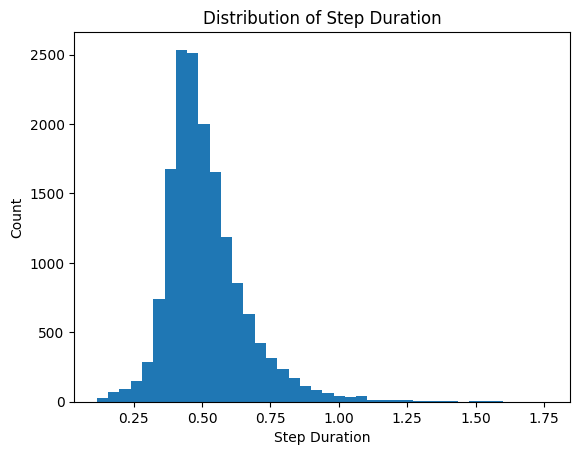

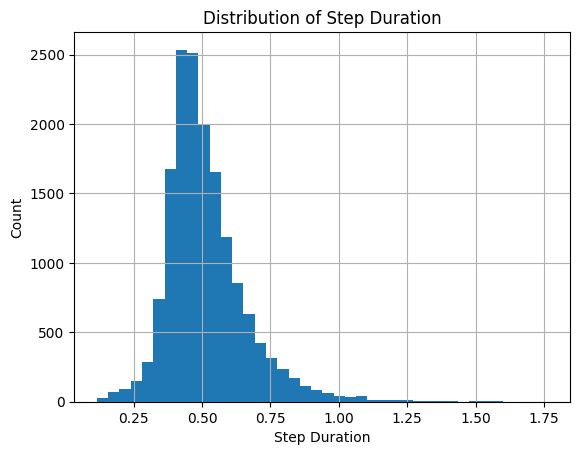

In [43]:
# First let's do one manually, simply. Say step duration.
# Step Duration histogram using Matplotlib directly
%matplotlib inline
plt.close("all")
plt.hist(
    df["Step_Duration"].dropna(),
    bins=40
)
plt.xlabel("Step Duration")
plt.ylabel("Count")
plt.title("Distribution of Step Duration")
plt.show()

# Same idea using the pandas plotting method
df["Step_Duration"].hist(
    bins=40
)
plt.xlabel("Step Duration")
plt.ylabel("Count")
plt.title("Distribution of Step Duration")
plt.show()

# If you haven't played with histogram bin numbers before, now is the time!
# What happens if you change the 40?

29 numerical measurement columns


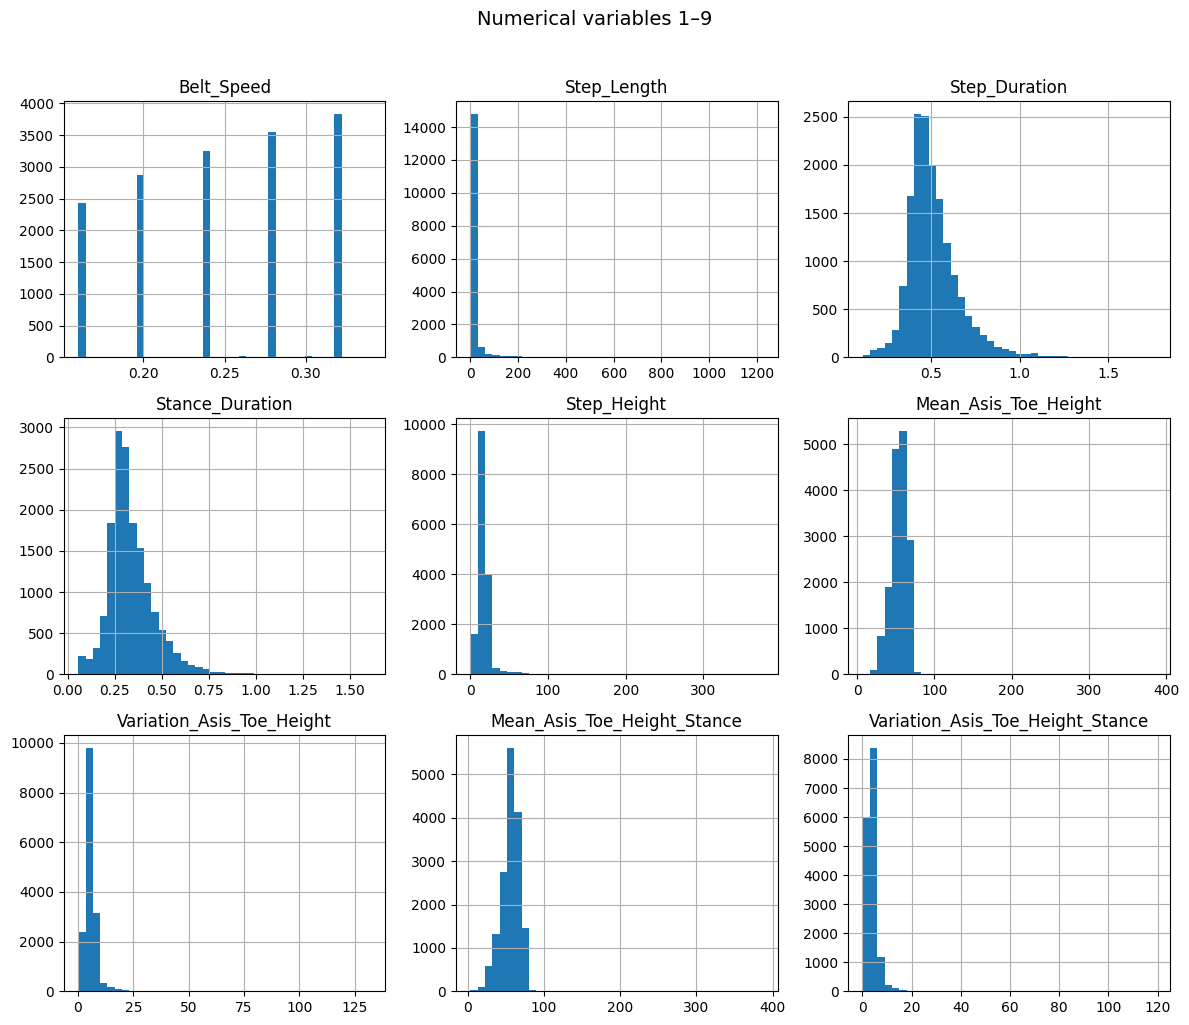

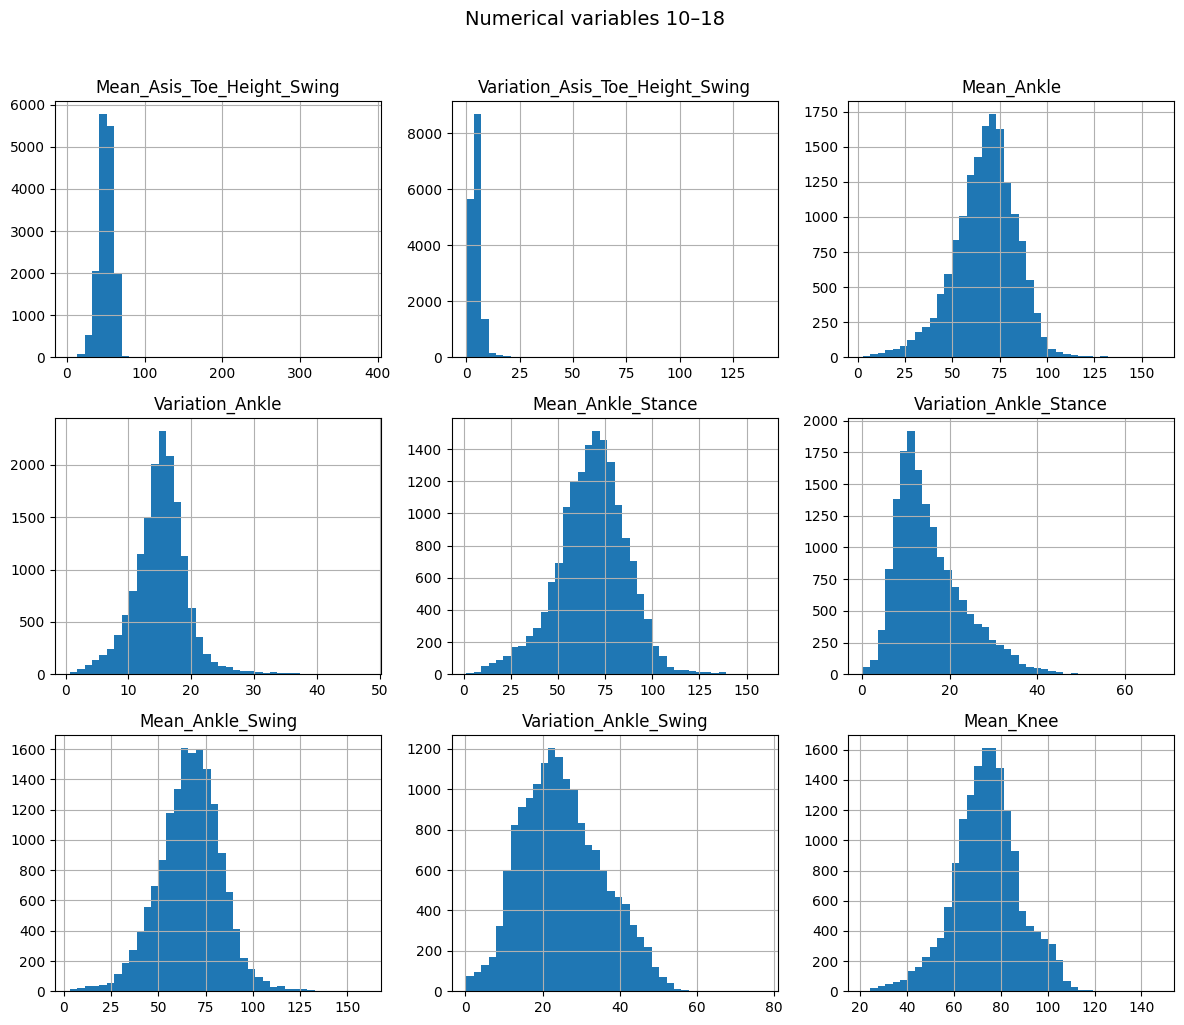

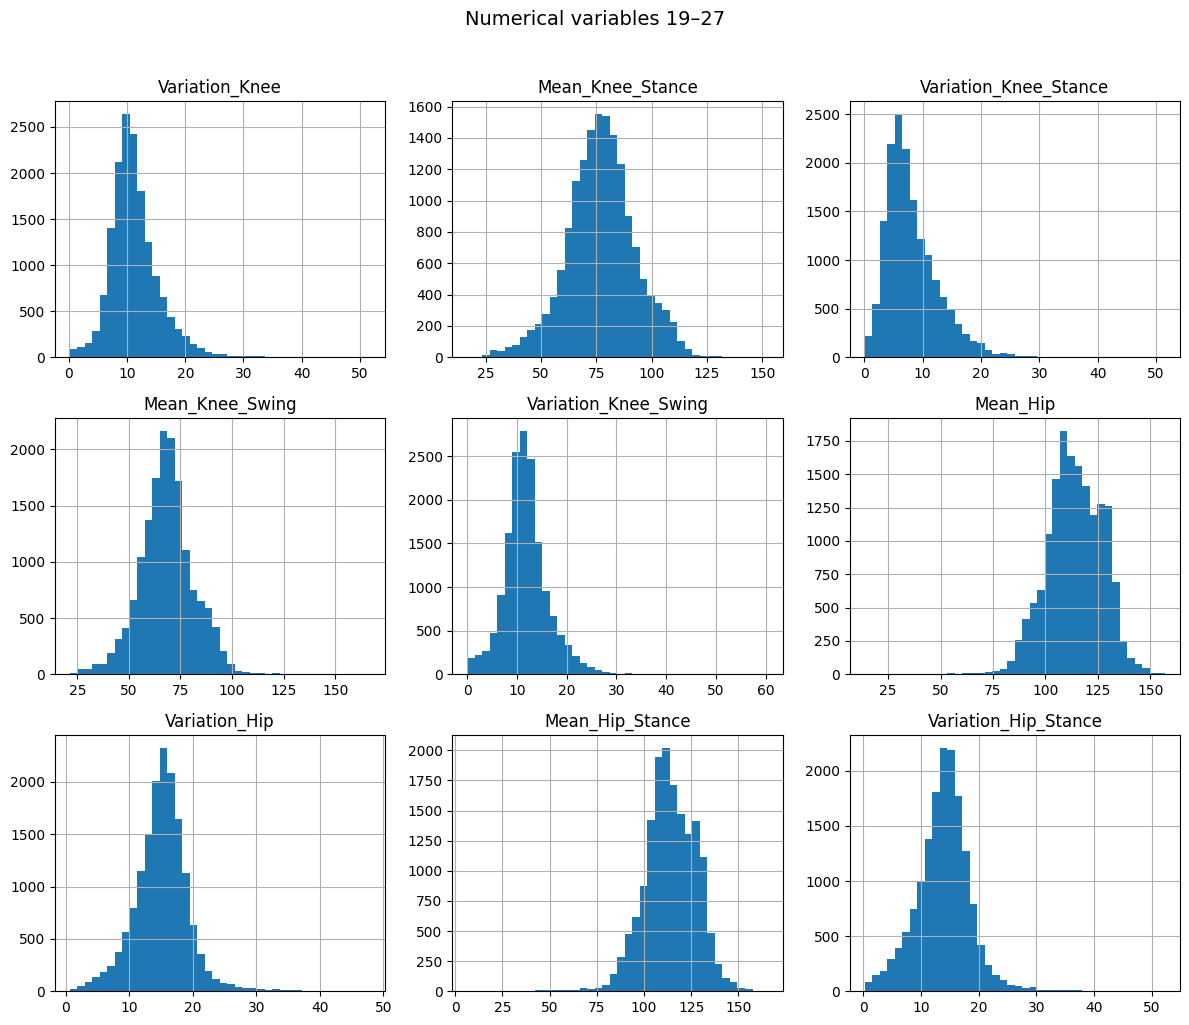

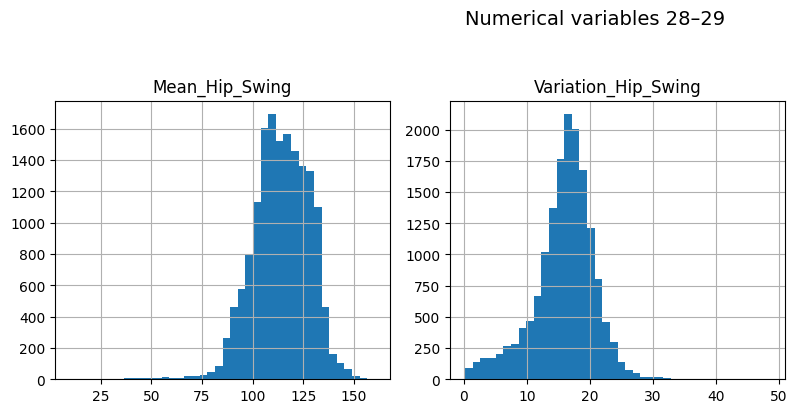

In [44]:
plt.close("all")
# Ok now let's go nuts and do all of them!
# Columns that are numeric but are really identifiers / indexing variables
exclude_numeric = [
    "Unnamed: 0",
    "Rat",
    "Stride",
]

numeric_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col not in exclude_numeric
]

print(f"{len(numeric_cols)} numerical measurement columns")

# Plot 9 variables at a time
for start in range(0, len(numeric_cols), 9):

    cols = numeric_cols[start:start + 9]

    axes = df[cols].hist(
        bins=40,
        figsize=(12, 10),
        layout=(3, 3),
    )

    plt.suptitle(
        f"Numerical variables {start + 1}–{start + len(cols)}",
        y=1.02,
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

In [46]:
# How did that automated code work?
cols

['Mean_Hip_Swing', 'Variation_Hip_Swing']

Now let's come back to our big picture, and task:

Supervised regression: can we predict Step_Height for an animal the model has never seen before?

So which columns would you **not** give to a model if the goal were to generalize to a new animal?

EG I want to give it a bunch of predictor data about a new raw, and have it try to spit out the correct Step_Height. So what do we give it?

In [47]:
# A working list to discuss in class.
# We will NOT use these as model features.

identifier_like = [
    "Unnamed: 0",
    "Name_File",
    "Study",
    "Rat",
    "Trial_Name",
    "Stride",
]

df[identifier_like].head()

,Unnamed: 0,Name_File,Study,Rat,Trial_Name,Stride
0,0,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,155,2020-07-13_11_06_34,1.0
1,1,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,155,2020-07-13_11_06_34,2.0
2,2,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,155,2020-07-13_11_06_34,3.0
3,3,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,155,2020-07-13_11_06_34,4.0
4,4,./Stride_Features.rat155.week-1_speed16.2020-0...,sb4,155,2020-07-13_11_06_34,5.0


# 2. Missing data

Do any columns have missing values?

Then we can ask **where** data are missing, not merely whether any `NaN` exists.

First, let's play around with isna(), sum() etc. to figure out how to get what we want:

In [48]:
df.isna().sum()

,0
Unnamed: 0,0
Name_File,0
Study,0
Speed_Group,0
Timepoint_Name,0
Rat,0
Belt_Speed,0
Trial_Name,0
Stride,0
Step_Length,0


In [49]:
# Ok now we can get fancier:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Variation_Hip,59
Mean_Hip_Stance,59
Variation_Hip_Stance,59
Mean_Ankle,59
Variation_Ankle,59
Mean_Hip_Swing,59
Variation_Hip_Swing,59
Variation_Knee,59
Mean_Knee,59
Variation_Ankle_Swing,59


If several biomechanical variables disappear on exactly the same rows, that may represent a **failed measurement or failed processing step**, not independent random missing values.

That distinction matters scientifically, because it might influence whether you need to fix a whole trial, or get rid of a whole rat, versus whether you just had a bad sensor point and can fill it safely with an imputer or filter.

### Question

Would replacing every missing kinematic value with the column median necessarily be the scientifically correct thing to do?

We'll use median imputation later because it is a useful machine-learning pipeline example, but preprocessing decisions should ultimately be justified by how the data were generated, per above.

In [50]:
missing_rows = df[df.isna().any(axis=1)]

print("Rows with at least one missing value:", len(missing_rows))

missing_trials = (
    missing_rows[
        ["Rat", "Timepoint_Name", "Speed_Group", "Trial_Name"]
    ]
    .drop_duplicates()
    .sort_values(["Rat", "Timepoint_Name", "Speed_Group"])
)

missing_trials

Rows with at least one missing value: 59


,Rat,Timepoint_Name,Speed_Group,Trial_Name
60,155,week-1,speed20,2020-07-13_11_47_51
3988,172,week2,speed20,2020-07-30_15_31_21
9105,195,week-1,speed16,2020-07-10_13_21_09
10269,195,week9,speed32,2020-09-15_16_09_34
10908,196,week6,speed20,2020-08-28_13_57_28
11012,196,week6,speed28,2020-08-28_14_47_16
11063,196,week6,speed32,2020-08-28_14_48_47


# 3. Is this longitudinal? And the power of crosstab!

A row is a stride, but the experiment is organized at several levels:

**strides → trials → speeds → time points → animals**

Let's inspect how many observations each animal contributes at each time point.

In [31]:
rat_time_counts = pd.crosstab(
    df["Rat"],
    df["Timepoint_Name"],
)

rat_time_counts

Timepoint_Name,week-1,week1,week2,week4,week6,week7,week8,week9
Rat,,,,,,,,
155,209,0,0,179,0,0,0,0
162,161,130,153,158,153,160,173,0
166,150,152,152,147,152,161,152,0
169,198,152,152,151,153,144,158,0
172,175,131,161,144,150,154,142,0
173,207,86,147,164,204,183,0,182
174,172,129,133,143,148,153,0,162
190,175,130,136,146,146,151,0,154
191,176,136,153,161,165,183,0,173


## A quick longitudinal view

To avoid mixing every speed together, let's look at one nominal speed group and summarize each rat/time point by its **median** `Step_Height`.

This is exploratory visualization, not yet a formal statistical analysis.

This goes *REALLY* fast... see the step by step sub-notebook!

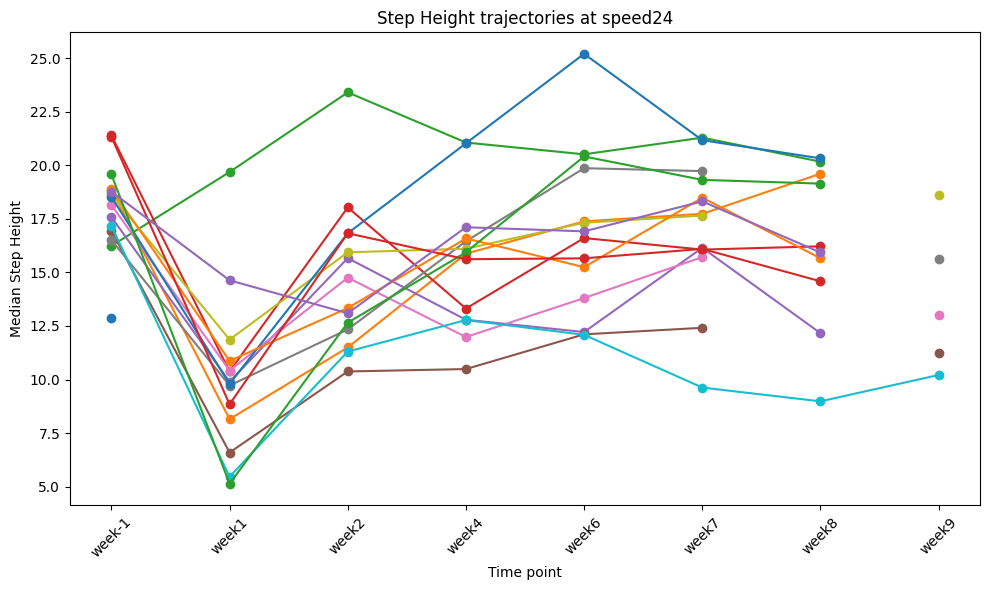

In [51]:
%matplotlib inline
time_order = [
    "week-1", "week1", "week2", "week4",
    "week6", "week7", "week8", "week9"
]

example_speed = "speed24"

trajectory = (
    df[df["Speed_Group"] == example_speed]
    .groupby(["Rat", "Timepoint_Name"])["Step_Height"]
    .median()
    .unstack()
    .reindex(columns=time_order)
)

ax = trajectory.T.plot(
    marker="o",
    figsize=(10, 6),
    legend=False,
)

ax.set_xlabel("Time point")
ax.set_ylabel("Median Step Height")
ax.set_title(f"Step Height trajectories at {example_speed}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interactive figure controls

With `%matplotlib widget`, use the figure toolbar to pan and zoom.

For a reproducible export, save explicitly from code:

```python
fig.savefig("step_height_trajectories.png", dpi=300, bbox_inches="tight")
```

The toolbar is great for exploration. `savefig()` is preferable when the exact output matters.

# 4. Scout candidate outcomes before choosing a target

Reminder: the **target** is the variable you are trying to predict with other variables. For example, let's say you have data from a FitBit on people, and you want to predict whether they have drop-foot. The FitBit doesn't measure how high their ankle raises, which is the problem with drop-foot - people can't raise their toes up high enough using their ankle muscles. But the FitBit data gives you estimates of stride time, foot contact events, and acceleration data. You might find out you can predict ankle rise from those really well.

So we have an analogous example problem here: can we predict `Step_Height` from other variables? That would be good, beause we suspect it will be a good predictor of spinal cord injury level and recovery. But how do you choose the target?

A target should not be chosen only because it gives the largest correlation or the easiest model.

Before settling on `Step_Height`, let's ask two descriptive questions:

1. Which candidate outcomes vary strongly with **belt speed**?
2. Which candidate outcomes show strong **baseline → week 4** longitudinal change?

We're worried about belt speed because it might confound our target with large changes, so maybe we look at one speed only.

This is dataset orientation, not model tuning. Once we define the prediction problem and create a test set, later EDA/model choices should use the training animals only.

In [28]:
candidate_outcomes = [
    "Step_Height",
    "Step_Length",
    "Step_Duration",
    "Stance_Duration",
    "Mean_Asis_Toe_Height",
    "Mean_Ankle",
    "Mean_Ankle_Swing",
    "Variation_Ankle_Swing",
    "Mean_Knee",
    "Variation_Knee_Swing",
    "Mean_Hip",
    "Variation_Hip_Swing",
]

speed_correlations = (
    df[candidate_outcomes + ["Belt_Speed"]]
    .corr(numeric_only=True)["Belt_Speed"]
    .drop("Belt_Speed")
    .sort_values(key=np.abs, ascending=False)
)

speed_correlations.to_frame("Pearson_r_with_Belt_Speed")

,Pearson_r_with_Belt_Speed
Stance_Duration,-0.490823
Step_Duration,-0.488675
Mean_Knee,0.130093
Mean_Ankle,0.097579
Mean_Ankle_Swing,0.067018
Variation_Hip_Swing,0.052021
Variation_Knee_Swing,0.042233
Step_Height,0.041515
Mean_Asis_Toe_Height,0.022097
Step_Length,-0.015506


The timing variables are expected to be strongly related to treadmill speed. That can make them scientifically sensible targets, but also somewhat **too easy** for our first regression exercise.

`Step_Height` is the maximum paw clearance during swing. It is biologically intuitive, continuous, and meaningfully predictable, while not being dominated by belt speed alone. That makes it a bit more interesting and challenging - like something you can't easily measure (requires motion capture) that you would predict with something else (accelerometer derived step parameters).

In [52]:
# A quick rat-level longitudinal scout.
# First summarize strides within speed, then summarize across speeds.

scout_rat_time_speed = (
    df
    .groupby(["Rat", "Timepoint_Name", "Speed_Group"])[candidate_outcomes]
    .median()
    .reset_index()
)

scout_rat_time = (
    scout_rat_time_speed
    .groupby(["Rat", "Timepoint_Name"])[candidate_outcomes]
    .median()
)

baseline_scout = scout_rat_time.xs("week-1", level="Timepoint_Name")
week4_scout = scout_rat_time.xs("week4", level="Timepoint_Name")

paired = baseline_scout.join(
    week4_scout,
    lsuffix="_baseline",
    rsuffix="_week4",
    how="inner",
)

effect_rows = []

for outcome in candidate_outcomes:
    delta = (
        paired[f"{outcome}_week4"]
        - paired[f"{outcome}_baseline"]
    ).dropna()

    sd_delta = delta.std(ddof=1)
    dz = delta.mean() / sd_delta if sd_delta > 0 else np.nan

    effect_rows.append({
        "Outcome": outcome,
        "Mean_change_week4_minus_baseline": delta.mean(),
        "Paired_effect_size_dz": dz,
        "N_rats": len(delta),
    })

longitudinal_scout = (
    pd.DataFrame(effect_rows)
    .sort_values(
        "Paired_effect_size_dz",
        key=np.abs,
        ascending=False,
    )
)

longitudinal_scout

,Outcome,Mean_change_week4_minus_baseline,Paired_effect_size_dz,N_rats
5,Mean_Ankle,18.758930,1.911334,15
2,Step_Duration,0.069067,1.876833,15
6,Mean_Ankle_Swing,19.948516,1.861040,15
7,Variation_Ankle_Swing,12.431552,1.518989,15
11,Variation_Hip_Swing,-2.616041,-1.192563,15
1,Step_Length,5.182913,1.156124,15
3,Stance_Duration,0.029600,1.094817,15
0,Step_Height,-2.544927,-0.844793,15
8,Mean_Knee,7.945585,0.791364,15
9,Variation_Knee_Swing,-2.040323,-0.599703,15


### Why keep `Step_Height`?

Some joint-angle and ROM-like variables show stronger longitudinal changes, and timing variables are more obviously speed dependent.

We're keeping `Step_Height` because it creates a richer modeling exercise:

- it is easy to interpret biologically
- it is not trivially determined by treadmill speed
- it has useful geometric/kinematic predictors
- it creates a natural later discussion about correlated predictors and related measures such as ASIS-toe height
- it remains relevant when we return to recovery and treatment effects

So the target is chosen for **scientific interpretability + teaching value**, not because it wins a univariate screening contest.

# 5. Frame a supervised ML problem

For the Chapter-2-style part of the exercise, let's define a concrete prediction problem:

> **Given other gait and joint-kinematic measurements from a stride, predict `Step_Height` for an animal that was not used to train the model.**

This is:

- **supervised learning**
- **regression**
- a prediction problem, **not** a causal analysis

The target is:

```python
Step_Height
```

### Critical question

What should the test set represent?

If the intended claim is:

> "This should work on a new animal"

then the test set must contain **whole animals the model has never seen**.

# 6. The most important biomedical wrinkle: repeated observations

There are thousands of rows, but far fewer independent animals.

A naive random row split can place:

- stride 12 from Rat 162 into training
- stride 19 from Rat 162 into training
- stride 27 from Rat 162 into testing

That makes the test set much less independent than it looks.

Let's demonstrate.

In [ ]:
from sklearn.model_selection import train_test_split

naive_train, naive_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
)

rats_in_both = set(naive_train["Rat"]) & set(naive_test["Rat"])

print("Rats represented in BOTH naive train and test:", len(rats_in_both))
print(sorted(rats_in_both))

## Split by animal instead

`GroupShuffleSplit` lets us keep all strides from a rat together.

In [ ]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_idx, test_idx = next(
    group_split.split(df, groups=df["Rat"])
)

train_raw = df.iloc[train_idx].copy()
test_raw = df.iloc[test_idx].copy()

print("Training rats:", sorted(train_raw["Rat"].unique()))
print("Test rats:    ", sorted(test_raw["Rat"].unique()))

overlap = set(train_raw["Rat"]) & set(test_raw["Rat"])

print("\nRat overlap:", overlap)
print("Training rows:", len(train_raw))
print("Test rows:", len(test_raw))

From this point forward:

## 🔒 Pretend `test_raw` is locked in a drawer.

Do exploration, preprocessing decisions, model comparison, and tuning using **training data only**.

We will open the test set once at the end.

# 7. Explore the training data

## 7A. Descriptive statistics

In [ ]:
train_raw[
    [
        "Step_Height",
        "Step_Length",
        "Step_Duration",
        "Stance_Duration",
        "Belt_Speed",
    ]
].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99, 0.995]
)

## 7B. Look for suspicious extremes

Biomedical datasets often contain values that are:

- biologically extreme but real
- tracking errors
- unit problems
- processing failures
- transcription errors

Do **not** automatically delete outliers merely because they are inconvenient.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train_raw["Step_Height"].dropna(), bins=80)
axes[0].set_xlabel("Step Height")
axes[0].set_ylabel("Count")
axes[0].set_title("Full Step Height distribution")

upper = train_raw["Step_Height"].quantile(0.995)

axes[1].hist(
    train_raw.loc[train_raw["Step_Height"] <= upper, "Step_Height"],
    bins=60,
)
axes[1].set_xlabel("Step Height")
axes[1].set_ylabel("Count")
axes[1].set_title("Zoomed to 99.5th percentile")

plt.tight_layout()
plt.show()

print("Largest Step Height values:")
display(
    train_raw.nlargest(10, "Step_Height")[
        ["Rat", "Timepoint_Name", "Speed_Group",
         "Step_Height", "Step_Length", "Trial_Name"]
    ]
)

### Discussion

Before removing an extreme observation, ask:

1. Is the value physically plausible?
2. Does the raw recording support it?
3. Is there a documented tracking failure?
4. Would the same rule be applied to future data?
5. Was the rule defined using training data only?

For this first ML exercise, we'll leave the observations in place and let model errors reveal some of the consequences.

## 7C. Correlations with Step Height

Correlation is not causation, and correlated predictors are common in biomechanics.

Still, this is a useful first look.

In [ ]:
exclude_for_correlation = [
    "Unnamed: 0",
    "Rat",
    "Stride",
]

numeric_training = (
    train_raw
    .drop(columns=exclude_for_correlation, errors="ignore")
    .select_dtypes(include="number")
)

correlations = (
    numeric_training
    .corr()["Step_Height"]
    .drop("Step_Height")
    .sort_values(key=np.abs, ascending=False)
)

correlations.head(15)

# 8. Correlated and redundant predictors

Biomedical variables often describe overlapping aspects of the same movement.

Examples in this dataset include:

- `Belt_Speed` and `Speed_Group`
- `Step_Duration` and `Stance_Duration`
- step geometry and related toe-height measures
- joint summaries calculated from the same stride

This is not automatically a problem, but it changes how we interpret models.

## Collinearity

When two predictors carry nearly the same information:

- a linear model can distribute the effect between them in unstable or unintuitive ways
- individual coefficients can change substantially when one correlated predictor is added or removed
- prediction can still be good even when coefficient interpretation is poor

Tree models handle redundancy differently, but feature importance can also be divided among correlated variables.

In [ ]:
correlation_demo_cols = [
    "Belt_Speed",
    "Step_Length",
    "Step_Duration",
    "Stance_Duration",
    "Step_Height",
    "Mean_Asis_Toe_Height",
    "Mean_Ankle",
    "Mean_Knee",
    "Mean_Hip",
]

corr_demo = (
    train_raw[correlation_demo_cols]
    .corr(numeric_only=True)
    .round(2)
)

corr_demo

## A deliberately redundant representation of speed

`Speed_Group` is essentially a categorical representation of the same experimental quantity described continuously by `Belt_Speed`.

Giving a linear model **both** can make its coefficients awkward to interpret.

Let's compare:

- Model A: continuous `Belt_Speed`
- Model B: `Belt_Speed` **plus** categorical `Speed_Group`

The point is not which model gets a better score. Watch what happens to the coefficient assigned to `Belt_Speed`.

In [ ]:
demo_numeric = [
    "Belt_Speed",
    "Step_Length",
    "Step_Duration",
    "Stance_Duration",
]

# Model A: continuous speed only
prep_a = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        demo_numeric,
    )
])

lin_a = Pipeline([
    ("prep", prep_a),
    ("model", LinearRegression()),
])

lin_a.fit(
    train_raw[demo_numeric],
    train_raw["Step_Height"],
)

coef_a = pd.Series(
    lin_a.named_steps["model"].coef_,
    index=lin_a.named_steps["prep"].get_feature_names_out(),
)

# Model B: same numeric predictors PLUS categorical Speed_Group
prep_b = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        demo_numeric,
    ),
    (
        "speed_group",
        OneHotEncoder(handle_unknown="ignore"),
        ["Speed_Group"],
    ),
])

lin_b = Pipeline([
    ("prep", prep_b),
    ("model", LinearRegression()),
])

lin_b.fit(
    train_raw[demo_numeric + ["Speed_Group"]],
    train_raw["Step_Height"],
)

coef_b = pd.Series(
    lin_b.named_steps["model"].coef_,
    index=lin_b.named_steps["prep"].get_feature_names_out(),
)

print("Model A: Belt_Speed coefficient")
display(coef_a[coef_a.index.str.contains("Belt_Speed")])

print("\nModel B: Belt_Speed + Speed_Group coefficients")
display(coef_b[coef_b.index.str.contains("Belt_Speed|speed_group")])

### Interpretation

If the `Belt_Speed` coefficient changes markedly after adding `Speed_Group`, nothing biological suddenly changed.

The model is being asked to divide the same information among redundant predictors.

This is one reason to distinguish:

> **good prediction**

from

> **clean interpretation of individual coefficients**

For our main models below, we will use **continuous `Belt_Speed`** and leave out `Speed_Group` so we do not feed the same speed information twice.

# 9. Feature engineering

Good features often encode scientifically meaningful relationships.

Two simple gait-derived quantities are:

### Swing duration

```text
Swing Duration = Step Duration - Stance Duration
```

### Duty factor

```text
Duty Factor = Stance Duration / Step Duration
```

These are constructed only from predictor information, not from `Step_Height`.

In [ ]:
def add_derived_features(frame):
    out = frame.copy()

    out["Swing_Duration"] = (
        out["Step_Duration"] - out["Stance_Duration"]
    )

    out["Duty_Factor"] = (
        out["Stance_Duration"] / out["Step_Duration"]
    )

    return out


train = add_derived_features(train_raw)
test = add_derived_features(test_raw)

train[
    [
        "Step_Duration",
        "Stance_Duration",
        "Swing_Duration",
        "Duty_Factor",
    ]
].head()

# 10. Choose predictors

For our **first model**, we'll deliberately leave out the ASIS-toe-height variables.

Why?

They may contain information very closely related to the geometry underlying `Step_Height`. Whether that is appropriate depends on the intended use of the model.

Later, we'll deliberately add an ASIS-height variable and ask:

> Is this a legitimate predictor, a redundant proxy, or information that would not really be available when we want to make the prediction?

That is a more useful question than automatically declaring every highly predictive variable "leakage."

We also deliberately use **continuous `Belt_Speed` without `Speed_Group`** in the main model. They encode essentially the same experimental quantity, and using both would make coefficient interpretation unnecessarily muddy.

## What is leakage?

In ML, **data leakage means the model gets information during training that it would not legitimately have when making a real prediction**. The result is a model that looks smarter on paper than it really is.

In this rat dataset, there are a few flavors of leakage to think about:

* **Train/test leakage:** strides from the same rat appear in both training and test sets. The model has effectively “met” the test animal already, even if it has not seen that exact stride. That is why splitting by whole rat matters.
* **Target leakage:** a predictor directly or indirectly contains information used to calculate `Step_Height`. If `ASIS_Toe_Height` were mathematically derived from the same coordinates in a way that nearly reconstructs paw clearance, then using it to predict `Step_Height` could be suspicious.
* **Preprocessing leakage:** computing something like the median, mean, scaler parameters, feature selection, or PCA using the entire dataset before splitting. The test set has then influenced the training pipeline.
* **Temporal leakage:** using information from a later time point to predict an earlier one. For example, using week 8 recovery data to predict week 4 status.
* **Label leakage:** accidentally leaving treatment labels, outcome codes, filenames, or other metadata in the feature set when those values reveal the answer.

The clean mental test is:

> **At the exact moment I would make this prediction in the real world, would I truly have access to this variable?**

If no, it is probably leakage.

An important distinction: **high correlation is not the same as leakage**. `Step_Length` can be highly predictive of `Step_Height` and still be perfectly legitimate if both are measured from the stride and Step Length would genuinely be available when the model is used.

Likewise, your ASIS-height variable may be a **proxy** or a redundant geometric measurement rather than true leakage. The deciding question is how it was computed and what the eventual use case is.

```text
Good model:
past/available measurements → predict unknown outcome

Leaky model:
information containing the answer → "predict" the answer
```

In [ ]:
target = "Step_Height"

joint_features = [
    col for col in train.columns
    if (
        col.startswith("Mean_Ankle")
        or col.startswith("Variation_Ankle")
        or col.startswith("Mean_Knee")
        or col.startswith("Variation_Knee")
        or col.startswith("Mean_Hip")
        or col.startswith("Variation_Hip")
    )
]

numeric_features = [
    "Belt_Speed",
    "Step_Length",
    "Step_Duration",
    "Stance_Duration",
    "Swing_Duration",
    "Duty_Factor",
] + joint_features

categorical_features = [
    "Timepoint_Name",
]

feature_columns = numeric_features + categorical_features

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Total model input columns:", len(feature_columns))

In [ ]:
X_train = train[feature_columns]
y_train = train[target]

X_test = test[feature_columns]
y_test = test[target]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 11. Build a preprocessing pipeline

Our table contains:

- numerical variables
- categorical variables
- some missing kinematic values

For numerical variables:

1. replace missing values with the training-set median
2. standardize to approximately zero mean / unit variance

For categorical variables:

1. replace missing categories if needed
2. one-hot encode the categories

Putting these steps into a `Pipeline`/`ColumnTransformer` helps prevent accidental preprocessing leakage.

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

preprocessor

# 12. Establish a boring baseline

Before celebrating a fancy model, ask whether it beats a trivial prediction.

Here the dummy model predicts the **median training Step Height** for everything.

In [ ]:
dummy_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="median")),
])

# 13. Compare several model families

We'll try:

- Dummy regression
- Linear regression
- A decision tree
- A random forest

But we still should **not use the held-out test rats to choose among them**.

Instead, perform cross-validation **inside the training animals**.

In [ ]:
models = {
    "Dummy": DummyRegressor(strategy="median"),

    "Linear regression": LinearRegression(),

    "Decision tree": DecisionTreeRegressor(
        max_depth=8,
        random_state=42,
    ),

    "Random forest": RandomForestRegressor(
        n_estimators=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
}

# Four folds keeps whole rats together while staying quick in class.
group_cv = GroupKFold(n_splits=3)

rows = []

for model_name, estimator in models.items():

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        groups=train["Rat"],
        cv=group_cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
        n_jobs=1,
    )

    rows.append({
        "Model": model_name,
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean(),
        "R2_SD": scores["test_R2"].std(),
    })

cv_results = (
    pd.DataFrame(rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

cv_results

### Questions

- Which model has the lowest cross-validated RMSE?
- Does the best model win on every metric?
- How variable is performance across groups of held-out animals?
- Why might animal-to-animal variability matter more than stride count here?

# 14. Optional stretch: small hyperparameter search

Chapter-2-style workflows often tune hyperparameters using cross-validation.

This can take longer, so it is left as an optional exercise.

**Important:** the folds still need to respect rat identity.

Uncomment the cell if you want to run it.

In [ ]:
# OPTIONAL STRETCH
#
# from sklearn.model_selection import GridSearchCV
#
# forest_pipeline = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", RandomForestRegressor(
#         random_state=42,
#         n_jobs=-1,
#     )),
# ])
#
# param_grid = {
#     "model__n_estimators": [50, 100],
#     "model__max_depth": [None, 12],
#     "model__min_samples_leaf": [1, 3],
# }
#
# search = GridSearchCV(
#     forest_pipeline,
#     param_grid=param_grid,
#     cv=GroupKFold(n_splits=3),
#     scoring="neg_root_mean_squared_error",
#     n_jobs=1,
# )
#
# search.fit(
#     X_train,
#     y_train,
#     groups=train["Rat"],
# )
#
# print("Best parameters:")
# print(search.best_params_)
#
# print("\nBest grouped-CV RMSE:")
# print(-search.best_score_)

# 15. Final evaluation on untouched rats

Now choose a model based on training-set cross-validation.

For this teaching example we'll use the random forest.

Fit it once on **all training rats**, then evaluate once on the held-out test rats.

In [ ]:
final_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
])

final_model.fit(X_train, y_train)

pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, pred)
test_rmse = mean_squared_error(y_test, pred) ** 0.5
test_r2 = r2_score(y_test, pred)

print(f"Held-out rats: {sorted(test['Rat'].unique())}")
print(f"MAE:  {test_mae:.3f}")
print(f"RMSE: {test_rmse:.3f}")
print(f"R²:   {test_r2:.3f}")

### Don't tune against this result repeatedly

Once you inspect the test performance, it is no longer a completely untouched source of evidence.

Repeatedly changing the model until the test score looks good turns the test set into another validation set.

## 15A. Predicted versus observed

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(y_test, pred, alpha=0.35)

cursor = mplcursors.cursor(sc, hover=True)
@cursor.connect("add")
def _hover_prediction(sel):
    row_pos = sel.index
    rat = test.iloc[row_pos]["Rat"]
    sel.annotation.set_text(
        f"Rat {rat}\nObserved = {sel.target[0]:.2f}\nPredicted = {sel.target[1]:.2f}"
    )

low = min(y_test.min(), pred.min())
high = max(y_test.max(), pred.max())

ax.plot([low, high], [low, high], linestyle="--")

ax.set_xlabel("Observed Step Height")
ax.set_ylabel("Predicted Step Height")
ax.set_title("Held-out animals: predicted vs observed")
plt.tight_layout()
plt.show()

## 15B. Residuals

Residual:

```text
observed - predicted
```

A useful model should not have an obvious systematic residual pattern.

In [ ]:
residuals = y_test.to_numpy() - pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(pred, residuals, alpha=0.35)
ax.axhline(0, linestyle="--")

ax.set_xlabel("Predicted Step Height")
ax.set_ylabel("Residual")
ax.set_title("Residuals on held-out animals")

plt.tight_layout()
plt.show()

# 16. What did the random forest use?

Tree-based models can provide a rough measure of feature importance.

This does **not** prove causation or biological importance. It tells us which inputs the fitted model found useful for prediction.

In [ ]:
feature_names = (
    final_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

importance_table = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
)

importance_table.head(15)

In [ ]:
top = importance_table.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(top["feature"], top["importance"])
ax.set_xlabel("Random-forest feature importance")
ax.set_title("Top predictive features")

plt.tight_layout()
plt.show()

# 17. ASIS-height experiment: leakage, proxy, or legitimate feature?

Now deliberately add:

```python
Mean_Asis_Toe_Height
```

and ask whether model performance changes.

### Important distinction

A feature is not automatically "leakage" merely because it is highly predictive.

Ask instead:

- Was this measurement available at the time the prediction would be made?
- Was it calculated from the target itself?
- Is it essentially another measurement of the same physical quantity?
- Would we have this feature in the intended real-world application?

In biomechanics, simultaneous geometrically related measures can be **redundant proxies** without necessarily being classical train/test leakage.

In [ ]:
asis_feature = "Mean_Asis_Toe_Height"

numeric_features_with_asis = numeric_features + [asis_feature]
feature_columns_with_asis = (
    numeric_features_with_asis + categorical_features
)

numeric_pipeline_with_asis = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor_with_asis = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_with_asis,
        numeric_features_with_asis,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

forest_with_asis = Pipeline([
    ("preprocess", preprocessor_with_asis),
    ("model", RandomForestRegressor(
        n_estimators=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
])

asis_scores = cross_validate(
    forest_with_asis,
    train[feature_columns_with_asis],
    y_train,
    groups=train["Rat"],
    cv=GroupKFold(n_splits=3),
    scoring={
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
    n_jobs=1,
)

print(
    "With ASIS mean height, grouped-CV RMSE:",
    round(-asis_scores["test_RMSE"].mean(), 3)
)
print(
    "With ASIS mean height, grouped-CV R²:",
    round(asis_scores["test_R2"].mean(), 3)
)

print("\nCompare with the original Random Forest row:")
display(
    cv_results[
        cv_results["Model"] == "Random forest"
    ]
)

# 18. Return to the original mystery: which animals were treated?

Now we switch problems.

The treatment identities are hidden, so we **do not have labels** for supervised learning.

That means:

> "Predict treated vs untreated"

is not currently a supervised classification problem.

Instead, we can ask whether animals show **different multivariate recovery patterns**.

That is an **unsupervised exploratory problem**.

# 19. Change the unit of analysis before PCA

This is crucial.

Treatment was applied to **animals**, not individual strides.

So we should not feed 16,000 correlated strides into PCA and pretend we have 16,000 independent treatment examples.

Instead:

1. summarize strides within each rat × time point × speed
2. give each speed roughly equal weight
3. calculate change from baseline (`week-1`) to a common post-injury time (`week4`)
4. make **one row per rat**

In [ ]:
mystery_outcomes = [
    "Step_Height",
    "Step_Length",
    "Stance_Duration",
    "Mean_Asis_Toe_Height",
    "Mean_Ankle",
    "Mean_Knee",
    "Mean_Hip",
]

# First summarize strides within each nominal speed.
rat_time_speed = (
    df
    .groupby(
        ["Rat", "Timepoint_Name", "Speed_Group"]
    )[mystery_outcomes]
    .median()
    .reset_index()
)

# Then take the median across nominal speeds so that a speed
# with more recorded strides does not automatically dominate.
rat_time = (
    rat_time_speed
    .groupby(["Rat", "Timepoint_Name"])[mystery_outcomes]
    .median()
)

baseline = (
    rat_time
    .xs("week-1", level="Timepoint_Name")
)

week4 = (
    rat_time
    .xs("week4", level="Timepoint_Name")
)

change_week4 = (
    week4 - baseline
).dropna()

print("One row per rat:", change_week4.shape)

change_week4

### Why week 4?

For this first blind exercise, `week4` is useful because it is a common post-baseline time point represented across the animals.

Later, a better longitudinal model could use the **entire recovery trajectory** rather than collapsing it to one change score.

# 20. Standardize before PCA

The variables have different units and scales.

Without standardization, a numerically large variable could dominate the PCA simply because of its units.

In [ ]:
scaler = StandardScaler()

Z = scaler.fit_transform(change_week4)

pca = PCA(n_components=2)

PC = pca.fit_transform(Z)

pca_table = pd.DataFrame(
    PC,
    index=change_week4.index,
    columns=["PC1", "PC2"],
)

print(
    "Explained variance ratio:",
    np.round(pca.explained_variance_ratio_, 3)
)

pca_table

## Plot the animals in PCA space

The axes are new combinations of the original recovery measures.

Do any animals appear to separate into groups?

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    pca_table["PC1"],
    pca_table["PC2"],
    s=70,
)

cursor = mplcursors.cursor(sc, hover=True)

@cursor.connect("add")
def _hover_pca(sel):
    rat = pca_table.index[sel.index]
    sel.annotation.set_text(
        f"Rat {rat}\nPC1 = {sel.target[0]:.2f}\nPC2 = {sel.target[1]:.2f}"
    )

for rat, row in pca_table.iterrows():
    ax.annotate(
        str(rat),
        (row["PC1"], row["PC2"]),
        xytext=(5, 4),
        textcoords="offset points",
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Blind recovery patterns: baseline → week 4")

plt.tight_layout()
plt.show()

# 21. What do the principal components represent?

PCA gives us components, but interpretation still requires going back to the original variables.

The **loadings** show how strongly each original standardized variable contributes to each PC.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=mystery_outcomes,
    columns=["PC1_loading", "PC2_loading"],
)

loadings.sort_values(
    "PC1_loading",
    key=np.abs,
    ascending=False,
)

# 22. Blind clustering

Let's ask two clustering algorithms to split the 15 animals into two groups.

The cluster labels `0` and `1` are arbitrary. Neither automatically means "treated."

In [ ]:
kmeans = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=42,
)

kmeans_cluster = kmeans.fit_predict(Z)

hierarchical = AgglomerativeClustering(
    n_clusters=2
)

hier_cluster = hierarchical.fit_predict(Z)

blind_guess = pca_table.copy()

blind_guess["KMeans_cluster"] = kmeans_cluster
blind_guess["Hierarchical_cluster"] = hier_cluster

blind_guess = (
    blind_guess
    .reset_index()
    .sort_values(["KMeans_cluster", "Rat"])
)

blind_guess

### Do the clustering methods agree?

Agreement does not prove the clusters are biologically real.

Disagreement is also informative: it tells us the grouping is not robust to how similarity is defined.

In [ ]:
pd.crosstab(
    blind_guess["KMeans_cluster"],
    blind_guess["Hierarchical_cluster"],
    rownames=["KMeans"],
    colnames=["Hierarchical"],
)

## Visualize the K-means assignment

In [ ]:
plot_df = blind_guess.set_index("Rat")

fig, ax = plt.subplots(figsize=(8, 6))

for cluster in sorted(plot_df["KMeans_cluster"].unique()):

    subset = plot_df[
        plot_df["KMeans_cluster"] == cluster
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=80,
        label=f"Cluster {cluster}",
    )

    for rat, row in subset.iterrows():
        ax.annotate(
            str(rat),
            (row["PC1"], row["PC2"]),
            xytext=(5, 4),
            textcoords="offset points",
        )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Blind two-cluster solution")
ax.legend()

plt.tight_layout()
plt.show()

# 23. Translate the clustering back to biology

A cluster number by itself means nothing.

Let's compare the average **baseline → week 4 change** of the original variables in each K-means group.

In [ ]:
change_with_cluster = change_week4.copy()

change_with_cluster["Cluster"] = (
    pd.Series(
        kmeans_cluster,
        index=change_week4.index,
    )
)

cluster_change_summary = (
    change_with_cluster
    .groupby("Cluster")
    .mean()
    .T
)

cluster_change_summary

### Questions before making a blind guess

- Which outcome changes distinguish the clusters?
- Does one cluster look more like "recovery"?
- Are the apparent differences dominated by one or two unusual rats?
- Do PCA and clustering tell the same story?
- Does your scientific interpretation change if you remove one feature?
- Does your answer survive changing from median to mean aggregation?

Record your **blind treatment guess before the identities are revealed**.

In [ ]:
# Export a simple blind-guess table if desired.

blind_guess.to_csv(
    "mystery_dataset_blind_cluster_guess.csv",
    index=False,
)

blind_guess

# 24. Why not dPCA yet?

**Demixed PCA (dPCA)** can be useful when we already know experimental factors and want to separate variation associated with them, for example:

- treadmill speed
- time after injury
- treatment group
- interactions among those factors

But at this point **treatment is deliberately hidden**.

So ordinary PCA is the cleaner first tool for the blind discovery problem.

After treatment identities are revealed, it could be interesting later in the course to revisit the full longitudinal dataset and ask whether variation can be separated into dimensions associated with:

```text
speed × time × treatment
```

That would be a different question from today's blind clustering exercise.

# 25. Take-home lessons

### Data science lessons

- Inspect structure before modeling.
- A large row count does not guarantee a large number of independent subjects.
- Missingness has a mechanism.
- Outliers deserve scientific investigation.
- Feature engineering should encode meaningful relationships.
- Correlated predictors can support good prediction while making individual coefficients hard to interpret.
- Preprocessing belongs inside reproducible pipelines.
- Establish a boring baseline before celebrating a model.
- Use cross-validation for model selection.
- Keep the final test set genuinely held out.

### Biomedical ML lessons

- Split according to the scientific unit you want to generalize to.
- Repeated strides from the same rat are correlated.
- Prediction is not causation.
- Highly predictive features can be useful, redundant, or inappropriate depending on when and how they are measured.
- Treatment-level analyses should ultimately operate at the treatment unit: the animal.
- PCA finds directions of variation; it does not discover biological truth.
- Clusters are hypotheses to investigate, not labels handed down by mathematics.

### The mystery continues

After the treatment labels are revealed, we can finally turn the blind treatment question into a **supervised** problem and ask whether the same features genuinely discriminate treatment groups in held-out animals.